In [0]:
# Load the Excel file
df = pd.read_excel('/tmp/inventory_data/Inventory Data.xlsx')

print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nColumn names and types:")
print(df.dtypes)
print(f"\nFirst few rows:")
print(df.head(10).to_string())
print(f"\nBasic statistics:")
print(df.describe().to_string())
print(f"\nMissing values:")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("No missing values")

Dataset shape: 33,919 rows x 3 columns

Column names and types:
Order Date        datetime64[ns]
SKU ID                    object
Order Quantity           float64
dtype: object

First few rows:
  Order Date  SKU ID  Order Quantity
0 2022-11-19  3084CA            1.00
1 2022-06-30  2621AA           20.00
2 2023-04-19  1193BA          147.00
3 2023-05-21  1971AA           10.00
4 2022-03-31  3177CA           56.25
5 2022-07-04  1385CA           13.00
6 2022-06-28  1479CA            4.00
7 2022-12-21  1206BA           21.00
8 2022-05-06  1486CA            2.00
9 2022-05-14  1479CA           10.00

Basic statistics:
                          Order Date  Order Quantity
count                          33919    33919.000000
mean   2022-11-20 01:40:36.970429440      432.793196
min              2022-01-30 00:00:00        0.000015
25%              2022-08-28 00:00:00        2.000000
50%              2022-12-04 00:00:00        6.000000
75%              2023-03-09 00:00:00       36.294959
max      

In [0]:
from pyspark.sql import SparkSession

# Convert pandas DataFrame to Spark DataFrame
# First, rename columns to remove spaces
df_renamed = df.rename(columns={
    'Order Date': 'order_date',
    'SKU ID': 'sku_id',
    'Order Quantity': 'order_quantity'
})

spark_df = spark.createDataFrame(df_renamed)

# Show current catalog
print(f"Current catalog: {spark.catalog.currentCatalog()}")
print(f"Current database: {spark.catalog.currentDatabase()}")

# Create schemas for medallion architecture
spark.sql("CREATE SCHEMA IF NOT EXISTS bronze")
spark.sql("CREATE SCHEMA IF NOT EXISTS silver")
spark.sql("CREATE SCHEMA IF NOT EXISTS gold")

print("\n✓ Schemas created: bronze, silver, gold")

# Save to Bronze layer (raw data as-is)
bronze_table = "bronze.inventory_raw"
spark_df.write.format("delta").mode("overwrite").saveAsTable(bronze_table)

print(f"\n✓ Bronze layer created: {bronze_table}")
print(f"  Rows: {spark_df.count():,}")
print(f"  Columns: {len(spark_df.columns)}")
print(f"  Schema:")
spark_df.printSchema()

Current catalog: workspace
Current database: default

✓ Schemas created: bronze, silver, gold

✓ Bronze layer created: bronze.inventory_raw
  Rows: 33,919
  Columns: 3
  Schema:
root
 |-- order_date: timestamp (nullable = true)
 |-- sku_id: string (nullable = true)
 |-- order_quantity: double (nullable = true)



MODEL COMPARISON - INVENTORY ROTATION CLASSIFICATION

All Models Performance:
              Model  Accuracy  F1 Score  AUC-ROC  Training Time (s)
      Random Forest  1.000000  1.000000 1.000000           0.135905
  Gradient Boosting  1.000000  1.000000 1.000000           0.248580
            XGBoost  1.000000  1.000000 1.000000           0.033709
Logistic Regression  0.706897  0.706388 0.855682           0.049046

BEST MODEL SELECTION

3 models achieved perfect AUC-ROC of 1.0:
  - Random Forest (Training Time: 0.14s)
  - Gradient Boosting (Training Time: 0.25s)
  - XGBoost (Training Time: 0.03s)

🏆 WINNER: XGBoost
   Reason: Perfect AUC-ROC (1.0) with fastest training time (0.03s)



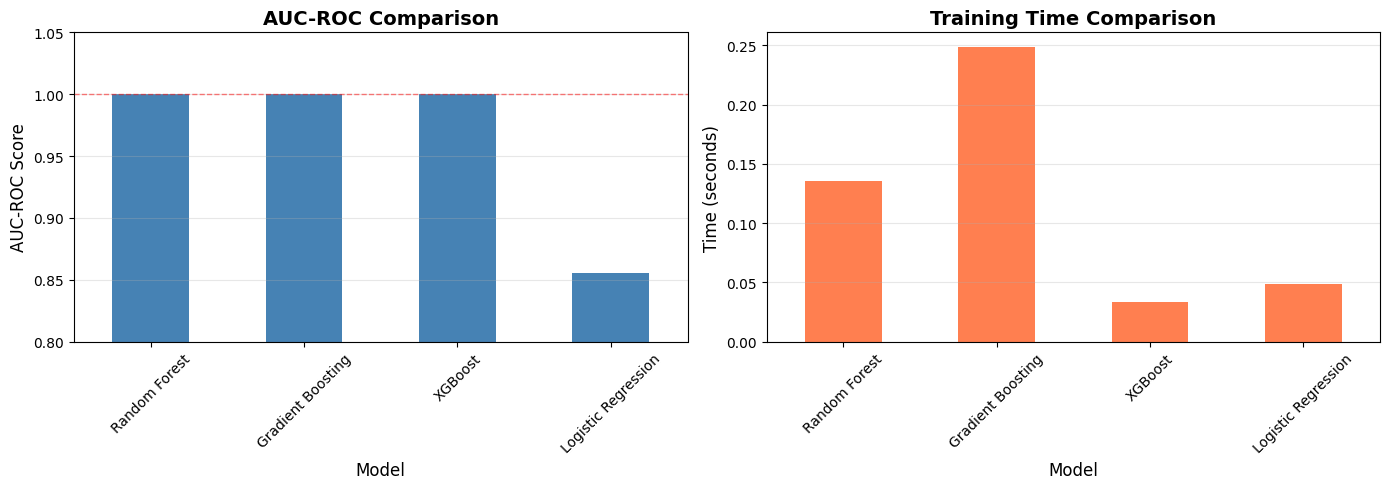


✓ Model comparison complete!


In [0]:
import pandas as pd
import matplotlib.pyplot as plt

# Create comparison DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('AUC-ROC', ascending=False)

print("="*70)
print("MODEL COMPARISON - INVENTORY ROTATION CLASSIFICATION")
print("="*70)
print("\nAll Models Performance:")
print(results_df.to_string(index=False))

# Find best model by AUC
best_model_idx = results_df['AUC-ROC'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
best_auc = results_df.loc[best_model_idx, 'AUC-ROC']

print("\n" + "="*70)
print("BEST MODEL SELECTION")
print("="*70)

# If there are multiple models with perfect AUC, select by other criteria
perfect_models = results_df[results_df['AUC-ROC'] == 1.0]

if len(perfect_models) > 1:
    print(f"\n{len(perfect_models)} models achieved perfect AUC-ROC of 1.0:")
    for _, row in perfect_models.iterrows():
        print(f"  - {row['Model']} (Training Time: {row['Training Time (s)']:.2f}s)")
    
    # Select fastest among perfect models
    fastest_idx = perfect_models['Training Time (s)'].idxmin()
    best_model_name = perfect_models.loc[fastest_idx, 'Model']
    best_time = perfect_models.loc[fastest_idx, 'Training Time (s)']
    
    print(f"\n🏆 WINNER: {best_model_name}")
    print(f"   Reason: Perfect AUC-ROC (1.0) with fastest training time ({best_time:.2f}s)")
else:
    print(f"\n🏆 WINNER: {best_model_name}")
    print(f"   AUC-ROC: {best_auc:.4f}")

print("\n" + "="*70)

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AUC comparison
ax1 = axes[0]
results_df.plot(x='Model', y='AUC-ROC', kind='bar', ax=ax1, color='steelblue', legend=False)
ax1.set_title('AUC-ROC Comparison', fontsize=14, fontweight='bold')
ax1.set_ylabel('AUC-ROC Score', fontsize=12)
ax1.set_xlabel('Model', fontsize=12)
ax1.set_ylim([0.8, 1.05])
ax1.axhline(y=1.0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Training time comparison
ax2 = axes[1]
results_df.plot(x='Model', y='Training Time (s)', kind='bar', ax=ax2, color='coral', legend=False)
ax2.set_title('Training Time Comparison', fontsize=14, fontweight='bold')
ax2.set_ylabel('Time (seconds)', fontsize=12)
ax2.set_xlabel('Model', fontsize=12)
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n✓ Model comparison complete!")

In [0]:
import mlflow
import mlflow.sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
import time

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Set MLflow experiment
mlflow.set_experiment("/Users/jesicaft@gmail.com/inventory-rotation-classification")

# Store results for comparison
results = []

# Define models to train
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, multi_class='ovr'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, max_depth=5, eval_metric='mlogloss')
}

print("Training models...\n")

# Train and evaluate each model
for model_name, model in models.items():
    with mlflow.start_run(run_name=model_name):
        start_time = time.time()
        
        # Train model
        model.fit(X_train_scaled, y_train)
        
        # Make predictions
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        auc_roc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
        
        training_time = time.time() - start_time
        
        # Log parameters and metrics to MLflow
        mlflow.log_param("model_type", model_name)
        mlflow.log_param("n_features", X_train.shape[1])
        mlflow.log_param("n_train_samples", X_train.shape[0])
        mlflow.log_param("n_test_samples", X_test.shape[0])
        
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("auc_roc", auc_roc)
        mlflow.log_metric("training_time_seconds", training_time)
        
        # Log model
        mlflow.sklearn.log_model(model, "model")
        
        # Store results
        results.append({
            'Model': model_name,
            'Accuracy': accuracy,
            'F1 Score': f1,
            'AUC-ROC': auc_roc,
            'Training Time (s)': training_time
        })
        
        print(f"{model_name}:")
        print(f"  Accuracy: {accuracy:.4f}")
        print(f"  F1 Score: {f1:.4f}")
        print(f"  AUC-ROC: {auc_roc:.4f}")
        print(f"  Training Time: {training_time:.2f}s\n")

print("\nAll models trained successfully!")

2026/05/05 17:49:15 INFO mlflow.tracking.fluent: Experiment with name '/Users/jesicaft@gmail.com/inventory-rotation-classification' does not exist. Creating a new experiment.


Training models...



/databricks/python/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
2026/05/05 17:49:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-41903424-2c32.cloud.databricks.com/ml/experiments/2151420868754520/models/m-4bf33ea0c0bb467e928166252330fd00?o=7474646192428017
2026/05/05 17:49:21 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructi

Logistic Regression:
  Accuracy: 0.7069
  F1 Score: 0.7064
  AUC-ROC: 0.8557
  Training Time: 0.05s



2026/05/05 17:49:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-41903424-2c32.cloud.databricks.com/ml/experiments/2151420868754520/models/m-19c96682ba5f4630bf0a2d11d4a5c8c6?o=7474646192428017
2026/05/05 17:49:25 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.


Random Forest:
  Accuracy: 1.0000
  F1 Score: 1.0000
  AUC-ROC: 1.0000
  Training Time: 0.14s



2026/05/05 17:49:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-41903424-2c32.cloud.databricks.com/ml/experiments/2151420868754520/models/m-f1b7bd0994f04afe8df873e4d1afc2a6?o=7474646192428017
2026/05/05 17:49:30 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.


Gradient Boosting:
  Accuracy: 1.0000
  F1 Score: 1.0000
  AUC-ROC: 1.0000
  Training Time: 0.25s



2026/05/05 17:49:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-41903424-2c32.cloud.databricks.com/ml/experiments/2151420868754520/models/m-48960c4cecb04ccb8d4f8227e8953cd1?o=7474646192428017
2026/05/05 17:49:34 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.


XGBoost:
  Accuracy: 1.0000
  F1 Score: 1.0000
  AUC-ROC: 1.0000
  Training Time: 0.03s


All models trained successfully!


In [0]:
from sklearn.model_selection import train_test_split
import numpy as np

# Load Gold layer
df_ml = spark.table("gold.inventory_rotation").toPandas()

print(f"Dataset shape: {df_ml.shape}")
print(f"\nTarget distribution:")
print(df_ml['rotation_category'].value_counts())

# Select features for ML
feature_cols = [
    'total_quantity',
    'order_count',
    'avg_order_quantity',
    'days_active',
    'days_since_last_order',
    'order_frequency',
    'turnover_velocity'
]

X = df_ml[feature_cols]
y = df_ml['rotation_label']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature statistics:")
print(X.describe())

# Split data into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTrain target distribution:")
print(y_train.value_counts().sort_index())
print(f"\nTest target distribution:")
print(y_test.value_counts().sort_index())

Dataset shape: (290, 13)

Target distribution:
rotation_category
Fast-moving      97
Medium-moving    97
Slow-moving      96
Name: count, dtype: int64

Features shape: (290, 7)
Target shape: (290,)

Feature statistics:
       total_quantity  order_count  ...  order_frequency  turnover_velocity
count    2.900000e+02   290.000000  ...       290.000000         290.000000
mean     5.062039e+04   116.962069  ...         0.284844         122.703853
std      2.363426e+05    75.880314  ...         0.220146         591.051247
min      5.000000e+00     1.000000  ...         0.006508           0.010846
25%      3.787500e+02    43.750000  ...         0.094271           0.835314
50%      9.050188e+02   126.500000  ...         0.258646           2.887132
75%      9.645100e+03   173.000000  ...         0.410867          24.035940
max      2.919070e+06   361.000000  ...         1.157718        7207.579291

[8 rows x 7 columns]

Train set: 232 samples
Test set: 58 samples

Train target distribution:
ro

In [0]:
from pyspark.sql.functions import col, when, ntile
from pyspark.sql.window import Window

# Create rotation categories based on turnover velocity percentiles
# Using ntile to divide into 3 equal groups
window_spec = Window.orderBy(col("turnover_velocity").desc())

df_gold = df_sku_metrics.withColumn(
    "velocity_percentile",
    ntile(3).over(window_spec)
)

# Create rotation category labels
df_gold = df_gold.withColumn(
    "rotation_category",
    when(col("velocity_percentile") == 1, "Fast-moving")
    .when(col("velocity_percentile") == 2, "Medium-moving")
    .otherwise("Slow-moving")
)

# Create numeric label for ML (0: Slow, 1: Medium, 2: Fast)
df_gold = df_gold.withColumn(
    "rotation_label",
    when(col("rotation_category") == "Fast-moving", 2)
    .when(col("rotation_category") == "Medium-moving", 1)
    .otherwise(0)
)

# Save to Gold layer
gold_table = "gold.inventory_rotation"
df_gold.write.format("delta").mode("overwrite").saveAsTable(gold_table)

print(f"✓ Gold layer created: {gold_table}")
print(f"\nRotation category distribution:")
df_gold.groupBy("rotation_category", "rotation_label").count().orderBy("rotation_label").show()

print("\nSample records:")
display(df_gold.select(
    "sku_id", "total_quantity", "order_count", "turnover_velocity", 
    "order_frequency", "rotation_category", "rotation_label"
).orderBy(col("turnover_velocity").desc()).limit(10))

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


✓ Gold layer created: gold.inventory_rotation

Rotation category distribution:
+-----------------+--------------+-----+
|rotation_category|rotation_label|count|
+-----------------+--------------+-----+
|      Slow-moving|             0|   96|
|    Medium-moving|             1|   97|
|      Fast-moving|             2|   97|
+-----------------+--------------+-----+


Sample records:


sku_id,total_quantity,order_count,turnover_velocity,order_frequency,rotation_category,rotation_label
2391CA,2919069.6128455503,176,7207.579290976668,0.4345679012345679,Fast-moving,2
2473CA,1330076.1802141708,178,4478.370977152091,0.5993265993265994,Fast-moving,2
2418CA,1721620.318948374,180,3758.9963295816024,0.3930131004366812,Fast-moving,2
2371CA,1096351.7182139943,177,2425.556898703527,0.3915929203539823,Fast-moving,2
1488BA,1642.0,1,1642.0,1.0,Fast-moving,2
3533CA,643314.0,226,1286.628,0.452,Fast-moving,2
1244AA,550590.1257956314,178,1202.1618467153526,0.388646288209607,Fast-moving,2
3619CA,504149.0,189,1010.3186372745491,0.3787575150300601,Fast-moving,2
2458CA,480129.86588931264,197,992.0038551432079,0.40702479338842973,Fast-moving,2
1116CA,425947.0,98,948.6570155902004,0.2182628062360802,Fast-moving,2


In [0]:
from pyspark.sql.functions import col, sum, count, avg, min, max, datediff, lit, current_date, when, ntile
from pyspark.sql.window import Window

# Read from Silver layer
df_silver = spark.table("silver.inventory_clean")

# Get the reference date (latest date in the dataset)
max_date = df_silver.select(max("order_date")).collect()[0][0]
print(f"Reference date (latest order): {max_date}")

# Aggregate at SKU level
df_sku_metrics = df_silver.groupBy("sku_id").agg(
    sum("order_quantity").alias("total_quantity"),
    count("*").alias("order_count"),
    avg("order_quantity").alias("avg_order_quantity"),
    min("order_date").alias("first_order_date"),
    max("order_date").alias("last_order_date")
)

# Calculate additional metrics
df_sku_metrics = df_sku_metrics \
    .withColumn("days_active", datediff(col("last_order_date"), col("first_order_date")) + 1) \
    .withColumn("days_since_last_order", datediff(lit(max_date), col("last_order_date"))) \
    .withColumn("order_frequency", col("order_count") / col("days_active")) \
    .withColumn("turnover_velocity", col("total_quantity") / col("days_active"))

# Handle edge cases (SKUs with only one order)
df_sku_metrics = df_sku_metrics \
    .withColumn("order_frequency", when(col("days_active") == 0, col("order_count")).otherwise(col("order_frequency"))) \
    .withColumn("turnover_velocity", when(col("days_active") == 0, col("total_quantity")).otherwise(col("turnover_velocity")))

print(f"\nTotal unique SKUs: {df_sku_metrics.count():,}")
print(f"\nSample metrics:")
df_sku_metrics.limit(5).toPandas().head()

Reference date (latest order): 2023-06-13 00:00:00

Total unique SKUs: 290

Sample metrics:


,sku_id,total_quantity,order_count,avg_order_quantity,first_order_date,last_order_date,days_active,days_since_last_order,order_frequency,turnover_velocity
0,3084CA,291.0,163,1.785276,2022-02-06,2023-06-13,493,0,0.330629,0.590264
1,2621AA,4490.0,93,48.279570,2022-01-30,2023-06-11,498,2,0.186747,9.016064
2,1193BA,21602.0,164,131.719512,2022-02-12,2023-06-13,487,0,0.336756,44.357290
3,1971AA,9994.0,85,117.576471,2022-01-31,2023-06-13,499,0,0.170341,20.028056
4,3177CA,19143.0,153,125.117647,2022-02-04,2023-06-13,495,0,0.309091,38.672727


In [0]:
from pyspark.sql.functions import col, year, month, quarter, dayofweek, current_date, datediff

# Read from Bronze layer
df_bronze = spark.table("bronze.inventory_raw")

# Add data enrichment
df_silver = df_bronze \
    .filter(col("order_quantity") > 0) \
    .withColumn("order_year", year(col("order_date"))) \
    .withColumn("order_month", month(col("order_date"))) \
    .withColumn("order_quarter", quarter(col("order_date"))) \
    .withColumn("order_day_of_week", dayofweek(col("order_date")))

print(f"Records before filtering: {df_bronze.count():,}")
print(f"Records after filtering (quantity > 0): {df_silver.count():,}")
print(f"Records removed: {df_bronze.count() - df_silver.count():,}")

# Save to Silver layer
silver_table = "silver.inventory_clean"
df_silver.write.format("delta").mode("overwrite").saveAsTable(silver_table)

print(f"\n✓ Silver layer created: {silver_table}")
print(f"\nSample data:")
df_silver.limit(5).toPandas().head()

Records before filtering: 33,919
Records after filtering (quantity > 0): 33,919
Records removed: 0

✓ Silver layer created: silver.inventory_clean

Sample data:


,order_date,sku_id,order_quantity,order_year,order_month,order_quarter,order_day_of_week
0,2022-10-08,2117BA,2.265266,2022,10,4,7
1,2023-05-21,2096AA,9.904651,2023,5,2,1
2,2022-09-16,1947CA,6.647228,2022,9,3,6
3,2023-03-30,1902BA,4.009080,2023,3,1,5
4,2022-09-11,1876AA,1.150430,2022,9,3,1


In [0]:
%pip install kaggle openpyxl xgboost --quiet

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import os
import pandas as pd

# Create directory for data
os.makedirs('/tmp/inventory_data', exist_ok=True)

# Download dataset from Kaggle
# Note: You may need to set up Kaggle API credentials first
# Place your kaggle.json in ~/.kaggle/ or set KAGGLE_USERNAME and KAGGLE_KEY environment variables
try:
    !kaggle datasets download -d fayez1/inventory-management -p /tmp/inventory_data --unzip
    print("✓ Dataset downloaded successfully")
except Exception as e:
    print(f"Error downloading dataset: {e}")
    print("\nTo set up Kaggle API:")
    print("1. Go to https://www.kaggle.com/settings/account")
    print("2. Click 'Create New Token' to download kaggle.json")
    print("3. Upload the file or set environment variables")

Dataset URL: https://www.kaggle.com/datasets/fayez1/inventory-management
License(s): unknown
100%|████████████████████████████████████████| 906k/906k [00:00<00:00, 15.0MB/s]

✓ Dataset downloaded successfully
